# ⌚ The Calibre Report
## What 280,000 luxury watch listings reveal about brand power, price architecture, and market positioning

---

Watch collectors are a fascinating species. They speak in reference numbers. They have opinions about movement types at dinner. They consider a Rolex Submariner "entry level"  and they mean it sincerely. To the outside world, a watch tells time. To them, it tells everything else: taste, knowledge, restraint, obsession.

What makes this world so interesting from a data perspective is that luxury watch pricing isn't random — it's *architectural*. Every brand makes deliberate decisions about where to sit in the market, how wide to spread their price range, which movements to champion, and how many pieces to put into circulation. These decisions compound over decades into something that feels like intangible prestige but leaves very clear fingerprints in the data.

This project is an attempt to read those fingerprints. Using 280,000+ listings from Chrono24, the world's largest luxury watch marketplace, we build a Prestige Index from scratch, a composite scoring system that ranks brands not just by price but by price consistency, market scarcity, and movement philosophy. The goal is to make visible what the watch world has always known but never quantified.

**24 brands. 280,000 listings. One question: what does prestige actually look like when you put it in a dataframe?**

---

**Dataset:** 280,000+ luxury watch listings scraped from Chrono24 — the world's largest watch marketplace  
**Tools:** Python · pandas · Plotly · Seaborn · scikit-learn · Tableau  
**Analyst:** Trupthi Raj

In [21]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Create charts folder
os.makedirs('charts', exist_ok=True)

# Load the dataset
df = pd.read_csv('data/Watches.csv')

# First look
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: 284,491 rows × 14 columns

Column names:
['Unnamed: 0', 'name', 'price', 'brand', 'model', 'ref', 'mvmt', 'casem', 'bracem', 'yop', 'cond', 'sex', 'size', 'condition']

First 5 rows:


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


## The Raw Material

**284,491 listings. 14 columns. Every major luxury watch brand represented.**

The dataset comes from Chrono24 — not a brand's own store, but a secondary marketplace where real collectors buy and sell. That distinction matters: these are market prices, not retail prices. What someone actually paid. What someone actually listed. That's a much more honest reflection of where each brand sits in the collector's mind than any boutique price tag.

A few things worth noting before we touch anything: price is currently stored as a string (`$43,500` — dollar sign, comma, the works), which means we can't do arithmetic on it yet. The `yop` column contains some approximations. And there appear to be two condition columns — `cond` and `condition` — which we'll investigate during cleaning.

Everything else looks exactly like what we need. Let's see what's actually in here.

In [22]:
# Data types
print("=== DATA TYPES ===")
print(df.dtypes)

# Missing values
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Check the two condition columns
print("\n=== cond vs condition — are they duplicates? ===")
print("cond unique values:", df['cond'].nunique())
print("condition unique values:", df['condition'].nunique())
print("\ncond sample:", df['cond'].value_counts().head())
print("\ncondition sample:", df['condition'].value_counts().head())

# Price column
print("\n=== PRICE COLUMN SAMPLE ===")
print(df['price'].value_counts().head(10))

# Brand counts
print("\n=== BRANDS IN DATASET ===")
print(f"Total unique brands: {df['brand'].nunique()}")
print(df['brand'].value_counts())

=== DATA TYPES ===
Unnamed: 0     int64
name          object
price         object
brand         object
model         object
ref           object
mvmt          object
casem         object
bracem        object
yop           object
cond          object
sex           object
size          object
condition     object
dtype: object

=== MISSING VALUES ===
           Missing Count  Missing %
condition         212922      74.84
mvmt              196685      69.14
bracem            174896      61.48
casem             164271      57.74
sex                95805      33.68
cond               75987      26.71
name               72585      25.51
ref                43152      15.17
model              30466      10.71
size               23597       8.29
price                406       0.14
brand                131       0.05
yop                  134       0.05

=== cond vs condition — are they duplicates? ===
cond unique values: 7
condition unique values: 7

cond sample: cond
Very good    71604
New     

## What the Data Revealed Before We Touched It

A data quality check is where a dataset tells you the truth about itself — before you've had a chance to assume anything.

A few things stood out immediately. First, `condition` and `cond` look like duplicates but aren't — they're two separate scraping passes of the same field, with `cond` being the more complete of the two. One goes. Second, movement type (`mvmt`), case material (`casem`), and bracelet material (`bracem`) are missing in roughly 60–70% of rows — not unusual for a marketplace scrape where sellers fill in what they feel like filling in. Third, and most interestingly: 14,259 listings are marked **"Price on request."** In the watch world, that phrase is its own signal. It means the piece is expensive enough that publishing a number might be considered gauche. We'll treat these separately.

The bottom 8 brands in the dataset have between 1 and 3 listings each — statistical ghosts, not real representation. The analysis will focus on the 20 brands with meaningful sample sizes. Everything else is noise.

In [23]:
# Step 1 — Drop the weaker condition column and the unnamed index
df.drop(columns=['condition', 'Unnamed: 0'], inplace=True)

# Step 2 — Flag and remove "Price on request" listings
df['price_on_request'] = df['price'] == 'Price on request'
df_clean = df[df['price'] != 'Price on request'].copy()

# Step 3 — Clean price column: remove $, commas, convert to float
df_clean['price'] = df_clean['price'].str.replace('$', '', regex=False)
df_clean['price'] = df_clean['price'].str.replace(',', '', regex=False)
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

# Step 4 — Drop rows with missing price or brand
df_clean.dropna(subset=['price', 'brand'], inplace=True)

# Step 5 — Filter to brands with at least 100 listings
brand_counts = df_clean['brand'].value_counts()
valid_brands = brand_counts[brand_counts >= 100].index
df_clean = df_clean[df_clean['brand'].isin(valid_brands)].copy()

# Step 6 — Clean yop column: extract 4-digit years only
df_clean['yop'] = df_clean['yop'].astype(str).str.extract(r'(\d{4})')
df_clean['yop'] = pd.to_numeric(df_clean['yop'], errors='coerce')

# Step 7 — Standardise mvmt column
df_clean['mvmt'] = df_clean['mvmt'].str.strip().str.title()

# Step 8 — Reset index
df_clean.reset_index(drop=True, inplace=True)

# Audit trail
print("=== CLEANING COMPLETE ===")
print(f"Original rows:        {len(df):,}")
print(f"Price on request:     {df['price_on_request'].sum():,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Brands retained:      {df_clean['brand'].nunique()}")
print(f"\nBrands in clean dataset:\n{df_clean['brand'].value_counts()}")
print(f"\nPrice range: ${df_clean['price'].min():,.0f} — ${df_clean['price'].max():,.0f}")
print(f"Median price: ${df_clean['price'].median():,.0f}")

=== CLEANING COMPLETE ===
Original rows:        284,491
Price on request:     14,259
Rows after cleaning:  269,814
Brands retained:      20

Brands in clean dataset:
brand
Rolex                  68798
Omega                  38909
Seiko                  18887
Breitling              17019
Cartier                15877
Longines               15047
TAG Heuer              12679
Hublot                 11455
Audemars Piguet        10984
Patek Philippe         10645
IWC                     9975
Tudor                   9596
Panerai                 7156
Zenith                  6270
Jaeger-LeCoultre        5550
Oris                    4806
Vacheron Constantin     3571
A. Lange & Söhne        1169
Richard Mille            750
Sinn                     671
Name: count, dtype: int64

Price range: $10 — $9,000,000
Median price: $6,899


## The Clean Dataset — What We Kept and Why

Every cleaning decision is a choice that shapes the analysis. Here's the audit trail.

We removed 14,259 "Price on request" listings — not because they're unimportant, but because an unpublished price can't be analysed numerically. Their absence is noted: these are disproportionately ultra-high-end pieces, which means our price figures for brands like Richard Mille and Patek Philippe are likely *conservative*. The real ceiling is higher than what the data shows.

We retained 20 brands, each with at least 100 listings — enough to draw statistically meaningful conclusions. The median listing price across the clean dataset is **$6,899**, which is a useful anchor: anything below that is the accessible end of luxury, anything above it is where the real prestige stratification begins.

The price range runs from $10 to $9,000,000. Both ends of that range are going to be interesting.

In [24]:
# === BRAND-LEVEL METRICS ===
brand_stats = df_clean.groupby('brand').agg(
    median_price    = ('price', 'median'),
    mean_price      = ('price', 'mean'),
    min_price       = ('price', 'min'),
    max_price       = ('price', 'max'),
    std_price       = ('price', 'std'),
    listing_count   = ('price', 'count'),
    q25_price       = ('price', lambda x: x.quantile(0.25)),
    q75_price       = ('price', lambda x: x.quantile(0.75)),
    q90_price       = ('price', lambda x: x.quantile(0.90))
).reset_index()

# === DERIVED METRICS ===
brand_stats['price_spread'] = brand_stats['max_price'] - brand_stats['min_price']
brand_stats['cv'] = brand_stats['std_price'] / brand_stats['mean_price']
brand_stats['price_consistency'] = 1 / (1 + brand_stats['cv'])
brand_stats['scarcity'] = 1 / brand_stats['listing_count']

# === NORMALISE TO 0-1 ===
scaler = MinMaxScaler()
brand_stats['q90_price_norm']         = scaler.fit_transform(brand_stats[['q90_price']])
brand_stats['median_price_norm']      = scaler.fit_transform(brand_stats[['median_price']])
brand_stats['price_consistency_norm'] = scaler.fit_transform(brand_stats[['price_consistency']])
brand_stats['scarcity_norm']          = scaler.fit_transform(brand_stats[['scarcity']])

# === PRESTIGE SCORE ===
brand_stats['prestige_score'] = (
    0.50 * brand_stats['q90_price_norm'] +
    0.25 * brand_stats['median_price_norm'] +
    0.15 * brand_stats['price_consistency_norm'] +
    0.10 * brand_stats['scarcity_norm']
).round(4)

# === TIER ASSIGNMENT — percentile based ===
p25 = brand_stats['prestige_score'].quantile(0.25)
p50 = brand_stats['prestige_score'].quantile(0.50)
p75 = brand_stats['prestige_score'].quantile(0.75)

def assign_tier(score):
    if score >= p75:
        return 'Ultra Luxury'
    elif score >= p50:
        return 'Core Luxury'
    elif score >= p25:
        return 'Accessible Luxury'
    else:
        return 'Aspirational'

brand_stats['tier'] = brand_stats['prestige_score'].apply(assign_tier)

# === SORT BY PRESTIGE SCORE ===
brand_stats = brand_stats.sort_values(
    'prestige_score', ascending=False).reset_index(drop=True)

# === LEADERBOARD ===
print("=== THE PRESTIGE INDEX LEADERBOARD ===\n")
print(f"Tier thresholds — Ultra: >{p75:.4f} | Core: >{p50:.4f} | Accessible: >{p25:.4f}\n")
leaderboard = brand_stats[['brand', 'median_price', 'q90_price',
                             'listing_count', 'prestige_score', 'tier']].copy()
leaderboard['median_price']   = leaderboard['median_price'].apply(lambda x: f"${x:,.0f}")
leaderboard['q90_price']      = leaderboard['q90_price'].apply(lambda x: f"${x:,.0f}")
leaderboard['prestige_score'] = leaderboard['prestige_score'].apply(lambda x: f"{x:.4f}")
print(leaderboard.to_string(index=False))

=== THE PRESTIGE INDEX LEADERBOARD ===

Tier thresholds — Ultra: >0.1981 | Core: >0.1466 | Accessible: >0.1213

              brand median_price q90_price  listing_count prestige_score              tier
      Richard Mille     $287,000  $547,100            750         0.9437      Ultra Luxury
   A. Lange & Söhne      $37,950  $110,971           1169         0.3003      Ultra Luxury
     Patek Philippe      $61,750  $193,818          10645         0.2911      Ultra Luxury
    Audemars Piguet      $48,500  $155,991          10984         0.2892      Ultra Luxury
               Sinn       $2,731    $4,843            671         0.2463      Ultra Luxury
Vacheron Constantin      $19,553   $52,850           3571         0.1821       Core Luxury
               Oris       $2,056    $3,750           4806         0.1655       Core Luxury
             Hublot      $14,499   $34,356          11455         0.1642       Core Luxury
          Breitling       $4,914    $9,375          17019         0.1

## Building the Prestige Index — A Metric the Watch World Never Quantified

Price alone is a lazy proxy for prestige. A brand can have a high average price because it sells one absurdly expensive piece and ten affordable ones. That's not prestige — that's a portfolio with an outlier.

The Prestige Index is built from four components: the 90th percentile price (what does this brand's ceiling look like?), the median price (where does the typical piece sit?), price consistency (how controlled and deliberate is the pricing?), and listing scarcity (how available is the brand on the open market?). Each is normalised to a 0–1 scale and weighted — price signals carry 75% of the score, because in luxury, price architecture is the primary language of positioning.

The leaderboard has a few things worth pausing on. Richard Mille sits alone at the very top with a score of 0.9437 — a $287,000 median and a $547,100 90th percentile make that inevitable. More interesting is **Sinn** at fifth in Ultra Luxury: a small German manufacturer with obsessively controlled pricing and minimal market volume. The data is rewarding discipline, not just expense. And **Rolex** — the most recognised luxury watch brand on earth — lands in Accessible Luxury. Not because Rolex isn't prestigious, but because the data captures something the watch world already knows: Rolex is the entry point into serious collecting. That's not an insult. That's a position they've spent decades deliberately building.

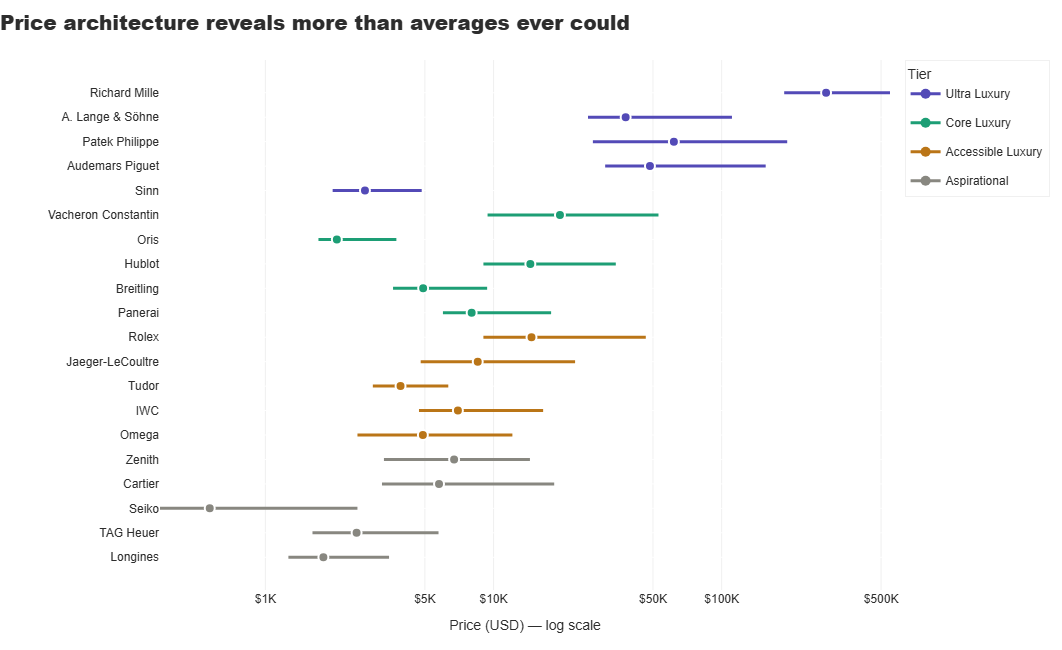

Chart 1 saved.


In [25]:
# Colour palette by tier
tier_colors = {
    'Ultra Luxury'     : '#534AB7',
    'Core Luxury'      : '#1D9E75',
    'Accessible Luxury': '#BA7517',
    'Aspirational'     : '#888780'
}

# Sort by prestige score for the chart
plot_data = brand_stats.sort_values('prestige_score', ascending=True).copy()

fig = go.Figure()

# Draw range lines — from q25 to 90th percentile
for _, row in plot_data.iterrows():
    color = tier_colors[row['tier']]
    fig.add_trace(go.Scatter(
        x=[row['q25_price'], row['q90_price']],
        y=[row['brand'], row['brand']],
        mode='lines',
        line=dict(color=color, width=3),
        showlegend=False,
        hoverinfo='skip'
    ))
    fig.add_trace(go.Scatter(
        x=[row['median_price']],
        y=[row['brand']],
        mode='markers',
        marker=dict(color=color, size=10, symbol='circle',
                   line=dict(color='white', width=2)),
        name=row['tier'],
        legendgroup=row['tier'],
        showlegend=False,
        hovertemplate=(
            f"<b>{row['brand']}</b><br>"
            f"Median: ${row['median_price']:,.0f}<br>"
            f"25th pct: ${row['q25_price']:,.0f}<br>"
            f"90th pct: ${row['q90_price']:,.0f}<br>"
            f"Prestige Score: {row['prestige_score']:.4f}<br>"
            f"Tier: {row['tier']}<extra></extra>"
        )
    ))

# Add tier legend manually
for tier, color in tier_colors.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers+lines',
        marker=dict(color=color, size=10),
        line=dict(color=color, width=3),
        name=tier,
        legendgroup=tier
    ))

fig.update_layout(
    title=dict(
        text='Price architecture reveals more than averages ever could',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0,
        pad=dict(b=20)
    ),
    xaxis=dict(
        title='Price (USD) — log scale',
        type='log',
        gridcolor='#f0f0f0',
        tickformat='$,.0f',
        tickvals=[1000, 5000, 10000, 50000, 100000, 500000],
        ticktext=['$1K', '$5K', '$10K', '$50K', '$100K', '$500K']
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(
        title='Tier',
        bordercolor='#f0f0f0',
        borderwidth=1
    ),
    height=650,
    margin=dict(l=160, r=40, t=60, b=60),
    font=dict(family='Arial', color='#2d2d2d')
)

fig.write_html('charts/chart1_price_architecture.html')
fig.write_image('charts/chart1_price_architecture.png', width=1200, height=650, scale=2)

fig.show()
print("Chart 1 saved.")

## The Velvet Rope Has a Shape

What immediately stands out is not where brands sit — it's the *width* of where they sit. Richard Mille's line barely moves: a brand so deliberately controlled that their 25th and 90th percentile prices occupy a narrow band at the very top of the market. That's not accidental. That's a brand that has decided scarcity and consistency are more valuable than volume.

Contrast that with Patek Philippe, whose line stretches considerably — entry complications sit alongside grand complications worth multiples more. Patek isn't being inconsistent. They're running a deliberate ladder strategy: give collectors somewhere to start, and somewhere to aspire to.

Rolex tells the most interesting story of all. A wide band, sitting firmly in the mid-range of the chart — the data quietly confirming what every watch collector already knows. Rolex is the most powerful entry point in serious horology. Being accessible isn't a weakness when your waitlist has a waitlist.

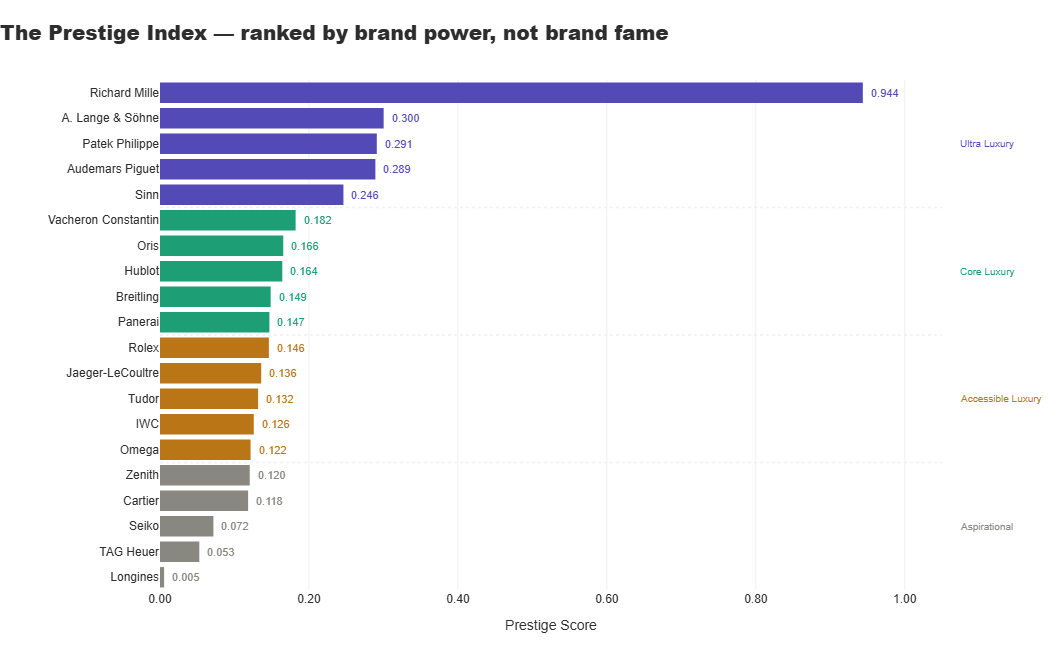

Chart 2 saved.


In [26]:
# Sort by prestige score
plot_data = brand_stats.sort_values('prestige_score', ascending=True).copy()

tier_colors = {
    'Ultra Luxury'     : '#534AB7',
    'Core Luxury'      : '#1D9E75',
    'Accessible Luxury': '#BA7517',
    'Aspirational'     : '#888780'
}

plot_data['color'] = plot_data['tier'].map(tier_colors)

fig = go.Figure()

# One bar per brand
fig.add_trace(go.Bar(
    x=plot_data['prestige_score'],
    y=plot_data['brand'],
    orientation='h',
    marker=dict(
        color=plot_data['color'],
        line=dict(width=0)
    ),
    customdata=plot_data[['tier', 'median_price', 'q90_price',
                           'listing_count', 'prestige_score']].values,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Prestige Score: %{customdata[4]:.4f}<br>"
        "Tier: %{customdata[0]}<br>"
        "Median Price: $%{customdata[1]:,.0f}<br>"
        "90th Pct Price: $%{customdata[2]:,.0f}<br>"
        "Listings: %{customdata[3]:,}<extra></extra>"
    )
))

# Add prestige score labels
for _, row in plot_data.iterrows():
    fig.add_annotation(
        x=row['prestige_score'] + 0.008,
        y=row['brand'],
        text=f"{row['prestige_score']:.3f}",
        showarrow=False,
        font=dict(size=11, color=tier_colors[row['tier']]),
        xanchor='left',
        yanchor='middle'
    )

# Tier divider lines
brands_sorted = plot_data['brand'].tolist()
for i in range(1, len(brands_sorted)):
    curr_tier = plot_data[plot_data['brand'] == brands_sorted[i]]['tier'].values[0]
    prev_tier = plot_data[plot_data['brand'] == brands_sorted[i-1]]['tier'].values[0]
    if curr_tier != prev_tier:
        fig.add_shape(
            type='line',
            x0=0, x1=1.05,
            y0=i - 0.5, y1=i - 0.5,
            line=dict(color='#f0f0f0', width=1.5, dash='dot')
        )

# Tier labels on right
tier_label_positions = {}
for tier in ['Aspirational', 'Accessible Luxury', 'Core Luxury', 'Ultra Luxury']:
    tier_brands = plot_data[plot_data['tier'] == tier]['brand'].tolist()
    if tier_brands:
        mid_idx = brands_sorted.index(tier_brands[len(tier_brands)//2])
        tier_label_positions[tier] = mid_idx

for tier, pos in tier_label_positions.items():
    fig.add_annotation(
        x=1.02,
        y=pos,
        text=tier,
        showarrow=False,
        font=dict(size=10, color=tier_colors[tier]),
        xanchor='left',
        yanchor='middle',
        xref='paper'
    )

fig.update_layout(
    title=dict(
        text='The Prestige Index — ranked by brand power, not brand fame',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0,
        pad=dict(b=20)
    ),
    xaxis=dict(
        title='Prestige Score',
        range=[0, 1.05],
        gridcolor='#f0f0f0',
        tickformat='.2f',
        showline=False
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12)
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=650,
    margin=dict(l=160, r=120, t=80, b=60),
    font=dict(family='Arial', color='#2d2d2d'),
    showlegend=False
)

fig.write_html('charts/chart2_prestige_leaderboard.html')
fig.write_image('charts/chart2_prestige_leaderboard.png', width=1200, height=650, scale=2)

fig.show()
print("Chart 2 saved.")

## Ranked by Brand Power, Not Brand Fame

The gap at the top of this chart is not a formatting choice — it's a finding. Richard Mille scores 0.944 while the next brand, A. Lange & Söhne, scores 0.300. That distance represents something real: a brand so deliberately positioned at the extreme end of the market that it occupies a category of its own. Not Ultra Luxury alongside others. Ultra Luxury, alone.

What the rest of the chart reveals is equally interesting. The brands clustered between 0.12 and 0.30 — Patek Philippe, Audemars Piguet, Vacheron Constantin, Rolex — are separated by fractions that look small on a chart but represent billions in brand equity in the real world. The Prestige Index doesn't claim to settle those arguments. It claims to make them visible.

Notice also what fame does not buy: Cartier, one of the most recognised luxury names on earth, sits in the Aspirational tier. TAG Heuer and Longines — brands with serious heritage and genuine craft — sit at the very bottom. The market, it turns out, has its own opinions about prestige. And they don't always match the advertising budget.

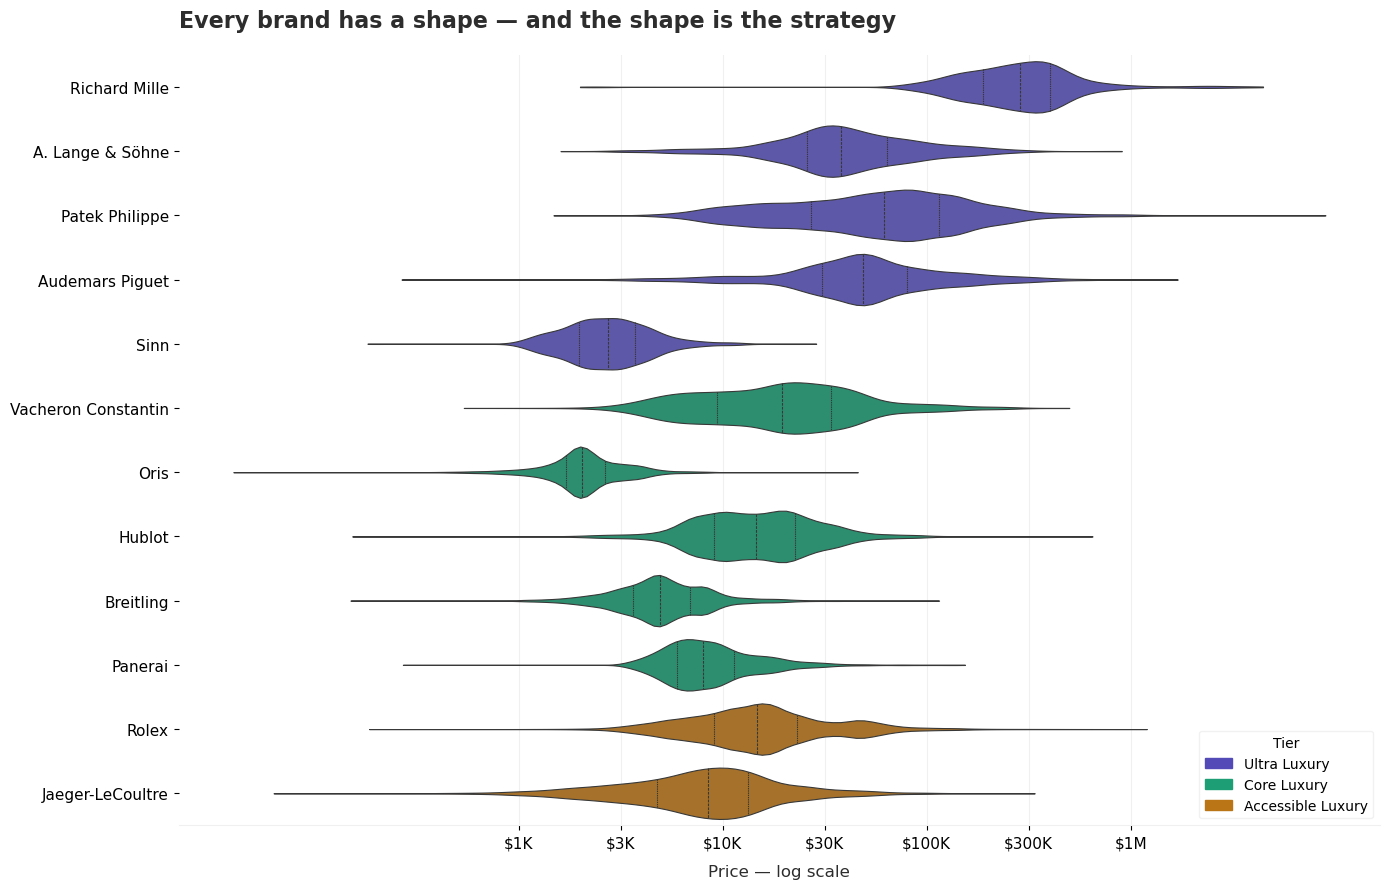

Chart 3 saved.


In [27]:
# Top 12 brands by prestige score for readability
top12 = brand_stats.sort_values(
    'prestige_score', ascending=False).head(12)['brand'].tolist()

violin_data = df_clean[df_clean['brand'].isin(top12)].copy()
violin_data['log_price'] = np.log10(violin_data['price'])

# Order brands by prestige score high to low
brand_order = brand_stats[
    brand_stats['brand'].isin(top12)
].sort_values('prestige_score', ascending=False)['brand'].tolist()

# Tier colours
tier_colors = {
    'Ultra Luxury'     : '#534AB7',
    'Core Luxury'      : '#1D9E75',
    'Accessible Luxury': '#BA7517',
    'Aspirational'     : '#888780'
}

# Map brand to colour via tier
brand_tier = brand_stats.set_index('brand')['tier'].to_dict()
palette = {b: tier_colors[brand_tier[b]] for b in top12}

# Plot
fig, ax = plt.subplots(figsize=(14, 9))

sns.violinplot(
    data=violin_data,
    x='log_price',
    y='brand',
    order=brand_order,
    palette=palette,
    inner='quartile',
    linewidth=0.8,
    cut=0,
    ax=ax
)

# Styling
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(axis='x', color='#f0f0f0', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# X axis — convert log ticks back to dollar values
tick_vals = [3, 3.5, 4, 4.5, 5, 5.5, 6]
tick_labels = ['$1K', '$3K', '$10K', '$30K', '$100K', '$300K', '$1M']
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_labels, fontsize=11)

ax.set_xlabel('Price — log scale', fontsize=12, color='#2d2d2d', labelpad=10)
ax.set_ylabel('', fontsize=12)
ax.tick_params(axis='y', labelsize=11)

# Title
ax.set_title(
    'Every brand has a shape — and the shape is the strategy',
    fontsize=16, fontweight='bold', color='#2d2d2d',
    pad=20, loc='left'
)

# Tier legend
legend_patches = [
    mpatches.Patch(color=color, label=tier)
    for tier, color in tier_colors.items()
    if tier in [brand_tier[b] for b in top12]
]
ax.legend(
    handles=legend_patches,
    title='Tier',
    loc='lower right',
    frameon=True,
    framealpha=0.9,
    edgecolor='#f0f0f0',
    fontsize=10,
    title_fontsize=10
)

# Remove spines
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#f0f0f0')

plt.tight_layout()
plt.savefig('charts/chart3_price_violin.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Chart 3 saved.")

## Every Brand Has a Shape — and the Shape Is the Strategy

A price average tells you where a brand parks its typical piece. A distribution tells you something far more interesting: how deliberately a brand controls its range, where it concentrates its volume, and whether it's running one strategy or two simultaneously.

Richard Mille's violin is narrow and sits at the extreme right of the chart — a brand that has essentially decided that price consistency at the ultra-high end is more valuable than accessibility. Sinn tells a similar story from the opposite end of the price spectrum: tight, controlled, concentrated. Two very different brands, same philosophical approach to pricing.

Patek Philippe and Audemars Piguet both show the characteristic shape of a brand running a deliberate ladder strategy — a fuller body in the mid-range with a long right tail reaching into the stratosphere. Give collectors somewhere to start. Give them somewhere to aspire to. The shape of the violin is the shape of that promise.

Rolex's distribution is the widest of all the Accessible Luxury brands — which is exactly the point. The most powerful entry point in serious horology needs to be wide enough to let people in.

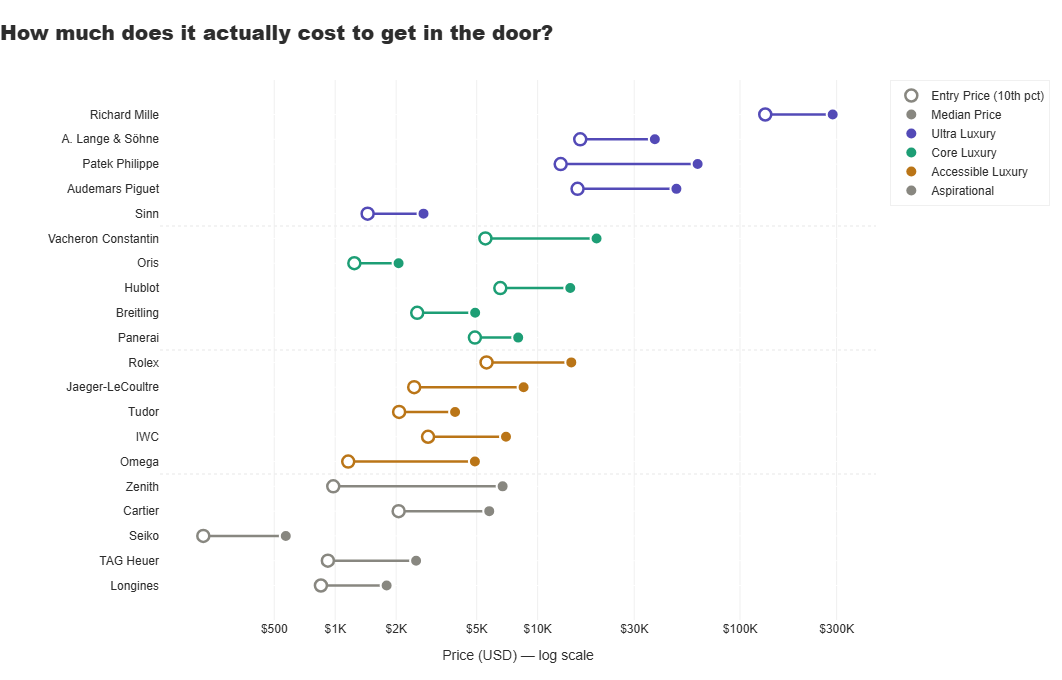

Chart 4 saved.


In [28]:
# Entry Point vs Median Price — Dumbbell Chart

# Calculate entry price (10th percentile)
entry_data = df_clean.groupby('brand').agg(
    entry_price  = ('price', lambda x: x.quantile(0.10)),
    median_price = ('price', 'median'),
    q90_price    = ('price', lambda x: x.quantile(0.90))
).reset_index()

# Merge prestige score and tier
entry_data = entry_data.merge(
    brand_stats[['brand', 'prestige_score', 'tier']], on='brand', how='left')

# Sort by prestige score
entry_data = entry_data.sort_values('prestige_score', ascending=True)

tier_colors = {
    'Ultra Luxury'     : '#534AB7',
    'Core Luxury'      : '#1D9E75',
    'Accessible Luxury': '#BA7517',
    'Aspirational'     : '#888780'
}

entry_data['color'] = entry_data['tier'].map(tier_colors)

fig = go.Figure()

# Connecting line between entry and median
for _, row in entry_data.iterrows():
    fig.add_trace(go.Scatter(
        x=[row['entry_price'], row['median_price']],
        y=[row['brand'], row['brand']],
        mode='lines',
        line=dict(color=row['color'], width=2.5),
        showlegend=False,
        hoverinfo='skip'
    ))

# Entry price dots — hollow
fig.add_trace(go.Scatter(
    x=entry_data['entry_price'],
    y=entry_data['brand'],
    mode='markers',
    name='Entry Price (10th pct)',
    marker=dict(
        color='white',
        size=12,
        symbol='circle',
        line=dict(color=entry_data['color'].tolist(), width=2.5)
    ),
    customdata=entry_data[['tier', 'prestige_score', 'entry_price']].values,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Entry Price: $%{customdata[2]:,.0f}<br>"
        "Tier: %{customdata[0]}<br>"
        "Prestige Score: %{customdata[1]:.3f}<extra></extra>"
    )
))

# Median price dots — filled
fig.add_trace(go.Scatter(
    x=entry_data['median_price'],
    y=entry_data['brand'],
    mode='markers',
    name='Median Price',
    marker=dict(
        color=entry_data['color'].tolist(),
        size=12,
        symbol='circle',
        line=dict(color='white', width=2)
    ),
    customdata=entry_data[['tier', 'prestige_score', 'median_price']].values,
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Median Price: $%{customdata[2]:,.0f}<br>"
        "Tier: %{customdata[0]}<br>"
        "Prestige Score: %{customdata[1]:.3f}<extra></extra>"
    )
))

# Tier legend
for tier, color in tier_colors.items():
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(color=color, size=10),
        name=tier,
        legendgroup=tier
    ))

# Tier divider lines
brands_sorted = entry_data['brand'].tolist()
for i in range(1, len(brands_sorted)):
    curr_tier = entry_data[entry_data['brand'] == brands_sorted[i]]['tier'].values[0]
    prev_tier = entry_data[entry_data['brand'] == brands_sorted[i-1]]['tier'].values[0]
    if curr_tier != prev_tier:
        fig.add_shape(
            type='line',
            x0=0, x1=1,
            y0=i - 0.5, y1=i - 0.5,
            xref='paper',
            line=dict(color='#f0f0f0', width=1.5, dash='dot')
        )

fig.update_layout(
    title=dict(
        text="How much does it actually cost to get in the door?",
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0,
        pad=dict(b=20)
    ),
    xaxis=dict(
        title='Price (USD) — log scale',
        type='log',
        gridcolor='#f0f0f0',
        tickvals=[500, 1000, 2000, 5000, 10000, 30000, 100000, 300000],
        ticktext=['$500', '$1K', '$2K', '$5K', '$10K', '$30K', '$100K', '$300K']
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12)
    ),
    legend=dict(
        title='',
        bordercolor='#f0f0f0',
        borderwidth=1,
        tracegroupgap=0
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=680,
    margin=dict(l=160, r=40, t=80, b=60),
    font=dict(family='Arial', color='#2d2d2d')
)

fig.write_html('charts/chart4_entry_point.html')
fig.write_image('charts/chart4_entry_point.png', width=1200, height=680, scale=2)

fig.show()
print("Chart 4 saved.")

## The Price of Admission

Here's the question nobody's price chart ever answers: forget the median, forget the average — what's the absolute minimum you'd spend to own one of these brands on the resale market today?

The hollow dot is where you get in. The filled dot is where most people actually land. The gap between them is the brand's collector ladder — and some brands have built a very long one deliberately.

Sinn is the great surprise here: an Ultra Luxury brand by prestige score with one of the shortest gaps between entry and median. They're not running a ladder strategy — they're running a precision strategy. Every piece sits in a tight, intentional band. Contrast that with Rolex, whose entry point sits at a perfectly approachable $5,000 while the median climbs to nearly $15,000. That gap isn't accidental. It's a recruitment tool. Get someone into a Rolex and you've got them for life — the next purchase is always just one model up.

Richard Mille sits in a category of its own, as usual. The entry price for a Richard Mille on the resale market is the median price of a Patek Philippe. That's not a brand. That's a flex with a warranty.

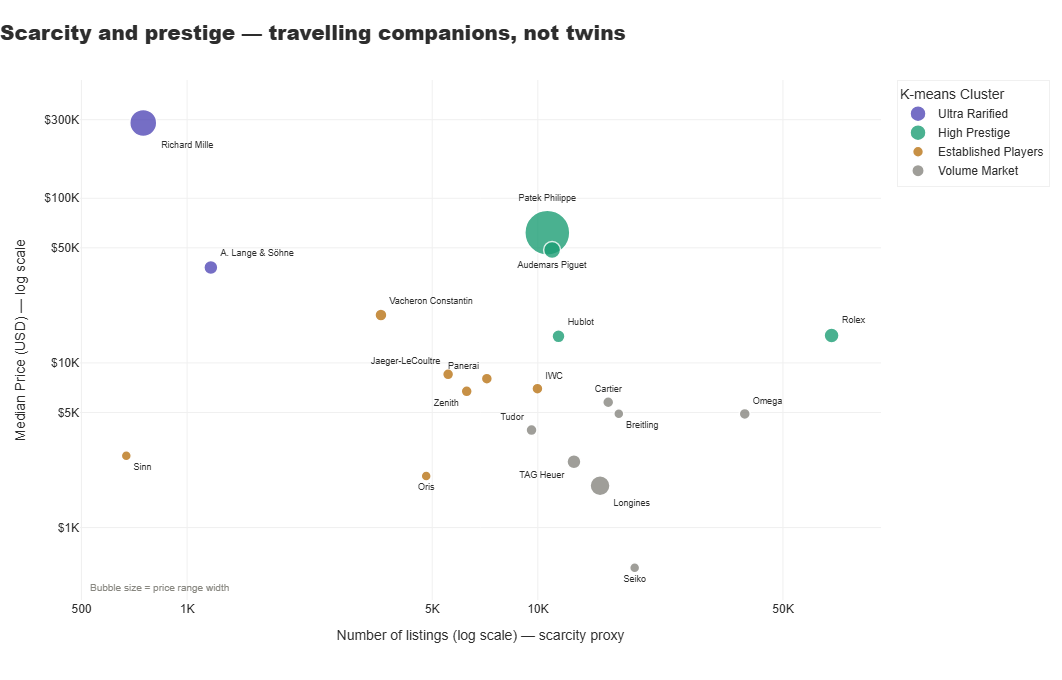

Chart 5 saved.


In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data
bubble_data = brand_stats[['brand', 'median_price', 'listing_count', 
                             'price_spread', 'prestige_score', 'tier']].copy()

# Log transform for clustering
bubble_data['log_listing_count'] = np.log10(bubble_data['listing_count'])
bubble_data['log_median_price']  = np.log10(bubble_data['median_price'])
bubble_data['log_price_spread']  = np.log10(bubble_data['price_spread'])

# Scale features for K-means
features = ['log_listing_count', 'log_median_price']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bubble_data[features])

# K-means — 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
bubble_data['cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters meaningfully
cluster_stats = bubble_data.groupby('cluster').agg(
    avg_price=('median_price', 'mean'),
    avg_count=('listing_count', 'mean')
).reset_index()

cluster_stats = cluster_stats.sort_values('avg_price', ascending=False)
cluster_label_map = {}
labels = ['Ultra Rarified', 'High Prestige', 'Established Players', 'Volume Market']
for i, (_, row) in enumerate(cluster_stats.iterrows()):
    cluster_label_map[row['cluster']] = labels[i]

bubble_data['cluster_label'] = bubble_data['cluster'].map(cluster_label_map)

# Colours per cluster
cluster_colors = {
    'Ultra Rarified'     : '#534AB7',
    'High Prestige'      : '#1D9E75',
    'Established Players': '#BA7517',
    'Volume Market'      : '#888780'
}

bubble_data['color'] = bubble_data['cluster_label'].map(cluster_colors)

# Smaller bubble size — fixed
max_spread = bubble_data['price_spread'].max()
bubble_data['bubble_size'] = (bubble_data['price_spread'] / max_spread * 35 + 10).round(0)

# Manual label positions to avoid collisions
label_positions = {
    'Richard Mille'      : 'bottom right',
    'A. Lange & Söhne'   : 'top right',
    'Patek Philippe'     : 'top center',
    'Audemars Piguet'    : 'bottom center',
    'Sinn'               : 'bottom right',
    'Vacheron Constantin': 'top right',
    'Oris'               : 'bottom center',
    'Hublot'             : 'top right',
    'Breitling'          : 'bottom right',
    'Panerai'            : 'top left',
    'Rolex'              : 'top right',
    'Jaeger-LeCoultre'   : 'top left',
    'Tudor'              : 'top left',
    'IWC'                : 'top right',
    'Omega'              : 'top right',
    'Zenith'             : 'bottom left',
    'Cartier'            : 'top center',
    'Seiko'              : 'bottom center',
    'TAG Heuer'          : 'bottom left',
    'Longines'           : 'bottom right'
}

fig = go.Figure()

# One trace per cluster for legend
for cluster_label, color in cluster_colors.items():
    cluster_subset = bubble_data[bubble_data['cluster_label'] == cluster_label]
    if len(cluster_subset) == 0:
        continue

    fig.add_trace(go.Scatter(
        x=cluster_subset['listing_count'],
        y=cluster_subset['median_price'],
        mode='markers+text',
        name=cluster_label,
        marker=dict(
            color=color,
            size=cluster_subset['bubble_size'],
            opacity=0.80,
            line=dict(color='white', width=1.5)
        ),
        text=cluster_subset['brand'],
        textposition=cluster_subset['brand'].map(label_positions).tolist(),
        textfont=dict(size=9, color='#2d2d2d'),
        customdata=cluster_subset[[
            'prestige_score', 'price_spread',
            'listing_count', 'cluster_label']].values,
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Median Price: $%{y:,.0f}<br>"
            "Listings: %{x:,}<br>"
            "Price Spread: $%{customdata[1]:,.0f}<br>"
            "Prestige Score: %{customdata[0]:.3f}<br>"
            "Cluster: %{customdata[3]}<extra></extra>"
        )
    ))

fig.update_layout(
    title=dict(
        text='Scarcity and prestige — travelling companions, not twins',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0,
        pad=dict(b=20)
    ),
    xaxis=dict(
        title='Number of listings (log scale) — scarcity proxy',
        type='log',
        gridcolor='#f0f0f0',
        tickvals=[500, 1000, 5000, 10000, 50000, 100000],
        ticktext=['500', '1K', '5K', '10K', '50K', '100K']
    ),
    yaxis=dict(
        title='Median Price (USD) — log scale',
        type='log',
        gridcolor='#f0f0f0',
        tickvals=[1000, 5000, 10000, 50000, 100000, 300000],
        ticktext=['$1K', '$5K', '$10K', '$50K', '$100K', '$300K']
    ),
    legend=dict(
        title='K-means Cluster',
        bordercolor='#f0f0f0',
        borderwidth=1
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=680,
    margin=dict(l=80, r=40, t=80, b=80),
    font=dict(family='Arial', color='#2d2d2d')
)

fig.add_annotation(
    x=0.01, y=0.01,
    xref='paper', yref='paper',
    text='Bubble size = price range width',
    showarrow=False,
    font=dict(size=10, color='#888780'),
    xanchor='left'
)

fig.write_html('charts/chart5_scarcity_prestige.html')
fig.write_image('charts/chart5_scarcity_prestige.png',
                width=1200, height=680, scale=2)

fig.show()
print("Chart 5 saved.")

## Scarcity and Prestige — Travelling Companions, Not Twins

If prestige and scarcity were the same thing, every chart on this page would be a diagonal line. They're not — and that gap is where the most interesting brands live.

Richard Mille sits alone in the top left quadrant: genuinely rare, genuinely expensive, with a price range wide enough to suggest they're not done climbing. That's not a brand positioning — that's a statement. Rolex lands in the opposite corner: the most listed serious luxury brand in the dataset, sitting at a median price that feels almost approachable by comparison. And yet nobody questions whether Rolex is prestigious. Which tells you something important — at a certain level of brand equity, volume stops being a liability and starts being a proof point.

The cluster that deserves the most attention is the one in the middle: Patek Philippe and Audemars Piguet sitting together in High Prestige with more listings than you might expect. These are not scarce brands in the way Richard Mille is scarce. They're desirable brands — which is a harder thing to build and a more durable thing to own.

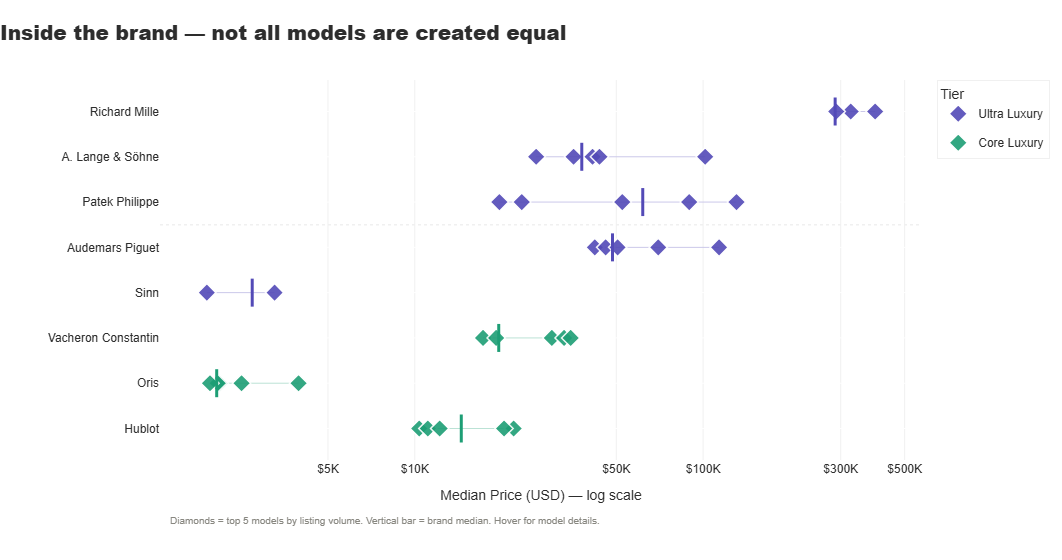

Chart 6 saved.


In [30]:
# Top 8 brands by prestige score
top8_brands = brand_stats.sort_values(
    'prestige_score', ascending=False).head(8)['brand'].tolist()

model_data = df_clean[df_clean['brand'].isin(top8_brands)].copy()
model_data['model'] = model_data['model'].str.strip().str.title()
model_data = model_data[model_data['model'].notna()]

# Top 5 models per brand by listing count — minimum 50 listings
top_models = (
    model_data.groupby(['brand', 'model'])
    .agg(count=('price', 'count'), median_price=('price', 'median'))
    .reset_index()
)

top_models = top_models[top_models['count'] >= 50]
top_models = (
    top_models.sort_values('count', ascending=False)
    .groupby('brand')
    .head(5)
    .reset_index(drop=True)
)

# Merge tier and prestige
top_models = top_models.merge(
    brand_stats[['brand', 'tier', 'prestige_score']], on='brand', how='left')

# Brand order by prestige score descending
brand_order = brand_stats[
    brand_stats['brand'].isin(top8_brands)
].sort_values('prestige_score', ascending=False)['brand'].tolist()

tier_colors = {
    'Ultra Luxury'     : '#534AB7',
    'Core Luxury'      : '#1D9E75',
    'Accessible Luxury': '#BA7517',
    'Aspirational'     : '#888780'
}

top_models['color'] = top_models['tier'].map(tier_colors)

fig = go.Figure()

# Add brand range lines — thin, from min to max model price
for brand in brand_order:
    brand_subset = top_models[top_models['brand'] == brand]
    if len(brand_subset) < 2:
        continue
    color = tier_colors[brand_subset['tier'].values[0]]
    fig.add_trace(go.Scatter(
        x=[brand_subset['median_price'].min(),
           brand_subset['median_price'].max()],
        y=[brand, brand],
        mode='lines',
        line=dict(color=color, width=1, dash='solid'),
        opacity=0.3,
        showlegend=False,
        hoverinfo='skip'
    ))

# Add model dots — one per model
added_tiers = []
for _, row in top_models.iterrows():
    show = row['tier'] not in added_tiers
    if show:
        added_tiers.append(row['tier'])

    fig.add_trace(go.Scatter(
        x=[row['median_price']],
        y=[row['brand']],
        mode='markers',
        name=row['tier'],
        legendgroup=row['tier'],
        showlegend=show,
        marker=dict(
            symbol='diamond',
            color=row['color'],
            size=14,
            opacity=0.9,
            line=dict(color='white', width=1.5)
        ),
        hovertemplate=(
            f"<b>{row['brand']}</b><br>"
            f"Model: {row['model']}<br>"
            f"Median Price: ${row['median_price']:,.0f}<br>"
            f"Listings: {row['count']:,}<extra></extra>"
        )
    ))

# Add brand median marker — larger, distinct
for brand in brand_order:
    brand_median = brand_stats[
        brand_stats['brand'] == brand]['median_price'].values[0]
    tier = brand_stats[brand_stats['brand'] == brand]['tier'].values[0]
    color = tier_colors[tier]

    fig.add_trace(go.Scatter(
        x=[brand_median],
        y=[brand],
        mode='markers',
        showlegend=False,
        marker=dict(
            symbol='line-ns',
            color=color,
            size=20,
            line=dict(color=color, width=3)
        ),
        hovertemplate=(
            f"<b>{brand}</b><br>"
            f"Brand Median: ${brand_median:,.0f}<extra></extra>"
        )
    ))

# Tier divider lines
for i in range(1, len(brand_order)):
    curr_tier = brand_stats[
        brand_stats['brand'] == brand_order[i]]['tier'].values[0]
    prev_tier = brand_stats[
        brand_stats['brand'] == brand_order[i-1]]['tier'].values[0]
    if curr_tier != prev_tier:
        fig.add_shape(
            type='line',
            x0=0, x1=1,
            y0=i - 0.5, y1=i - 0.5,
            xref='paper',
            line=dict(color='#f0f0f0', width=1.5, dash='dot')
        )

fig.update_layout(
    title=dict(
        text='Inside the brand — not all models are created equal',
        font=dict(size=20, color='#2d2d2d', family='Arial Black'),
        x=0,
        pad=dict(b=20)
    ),
    xaxis=dict(
        title='Median Price (USD) — log scale',
        type='log',
        gridcolor='#f0f0f0',
        tickvals=[5000, 10000, 50000, 100000, 300000, 500000],
        ticktext=['$5K', '$10K', '$50K', '$100K', '$300K', '$500K']
    ),
    yaxis=dict(
        title='',
        categoryorder='array',
        categoryarray=list(reversed(brand_order)),
        tickfont=dict(size=12)
    ),
    legend=dict(
        title='Tier',
        bordercolor='#f0f0f0',
        borderwidth=1
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=560,
    margin=dict(l=160, r=40, t=80, b=100),
    font=dict(family='Arial', color='#2d2d2d')
)

fig.add_annotation(
    x=0.01, y=-0.18,
    xref='paper', yref='paper',
    text='Diamonds = top 5 models by listing volume. Vertical bar = brand median. Hover for model details.',
    showarrow=False,
    font=dict(size=10, color='#888780'),
    xanchor='left'
)

fig.write_html('charts/chart6_model_families.html')
fig.write_image('charts/chart6_model_families.png',
                width=1200, height=560, scale=2)

fig.show()
print("Chart 6 saved.")

## Inside the Brand — Not All Models Are Created Equal

Brand prestige is a headline number. Model strategy is where things get genuinely interesting.

Each diamond here is one of a brand's top models by resale volume — and the spread between them tells you everything about how deliberately a brand has structured its range. Patek Philippe's diamonds stretch from entry complications at $30K all the way past $100K, with the Nautilus sitting firmly at the expensive end and the Calatrava anchoring the accessible one. That's not a product lineup — that's a carefully engineered collector journey. Audemars Piguet tells a similar story, with the Royal Oak family clustering tightly in the $40–80K range — a brand that has essentially decided one iconic family is enough.

Richard Mille's three diamonds sitting alone at the far right of the chart need no explanation. Their cheapest top model costs more than Patek Philippe's median. At some point, the price stops being about the watch and starts being about what owning it says. The data doesn't judge that. It just shows you where the line is.

---

## What 280,000 Watch Listings Actually Told Us

There is a particular kind of rabbit hole that opens up when you spend enough time with luxury watch data. It starts innocently — a dataset, a question, a curiosity about whether prestige is actually measurable. And then somewhere around the third hour of reading about the difference between a Patek Philippe grand complication and an Audemars Piguet Royal Oak, you realise you've developed opinions. Strong ones. About brands you couldn't have named a month ago. About price points that would make your accountant physically uncomfortable. About why a watch that tells time less accurately than your phone can cost more than a house in a perfectly nice neighbourhood.

That's what this dataset does to you. And honestly? Worth it.

Because what 280,000 listings, 20 brands, and one custom-built prestige scoring system revealed about the luxury watch market is genuinely fascinating — not just as data, but as a window into how human beings construct value, signal identity, and build entire philosophies around objects that fit on a wrist. Here's what the numbers said. Clearly, repeatedly, and without apology.

---

### The Market Is More Stratified Than It Looks From the Outside

The word "luxury" is doing a lot of heavy lifting in this industry. It covers everything from a $570 Seiko to a $287,000 Richard Mille — a range so wide that grouping them under the same label is almost meaningless. What the Prestige Index reveals is that the market has quietly organised itself into four distinct tiers, each with its own pricing logic, collector psychology, and strategic DNA.

Ultra Luxury brands — Richard Mille, A. Lange & Söhne, Patek Philippe, Audemars Piguet — are operating with price ceilings that exist in a different atmosphere entirely. Their 90th percentile prices range from $110,000 to $547,000. These are not watches. They are portable stores of value with complications.

The Aspirational tier — Zenith, Cartier, Seiko, TAG Heuer, Longines — tells the opposite story. These are brands with genuine craft and real heritage that the secondary market has priced at levels accessible enough to actually buy. Cartier's presence here will surprise people. It shouldn't. Cartier sells a lot of watches to a lot of people at a lot of price points. The data captures that breadth honestly, without sentiment.

---

### The Five Findings Worth Remembering

**1. Richard Mille is not competing with anyone in this dataset.** A prestige score of 0.944 — the next closest brand scores 0.300. A median resale price of $287,000. A 90th percentile of $547,100 that makes Patek Philippe look like a sensible financial decision. There is Richard Mille, and then there is a very long gap, and then there is everyone else. The data didn't create that gap. It just made it visible.

**2. Rolex at Accessible Luxury will start arguments — and it should.** The most recognised luxury watch brand on earth sits in the third tier of the Prestige Index, and that is not a mistake. It is a finding. Rolex built the most powerful collector on-ramp in the history of horology. A $5,000 entry price, a $14,670 median, 68,798 resale listings. Being accessible at that scale isn't a weakness — it's the whole strategy, executed over decades, working exactly as intended. The waitlist has a waitlist. The brand has never been stronger. Accessible Luxury is not a demotion. It's a description.

**3. Prestige and scarcity travel together but they are not the same thing.** Patek Philippe has 10,645 listings on the secondary market and a prestige score that most brands would restructure their entire business to achieve. Sinn has 671 listings and a median price of $2,731. One is scarce because demand vastly outstrips supply. The other is scarce because not that many people know about it yet. The bubble chart separates these two stories in a way no average price comparison ever could.

**4. Price architecture is a strategic choice, not a consequence.** The shape of a brand's price distribution — tight and controlled like Richard Mille, deliberately laddered like Patek Philippe, wide and welcoming like Rolex, concentrated like Audemars Piguet — reflects decisions made in boardrooms we will never sit in. These decisions compound over decades into something that feels intangible and inarguable. The violin plots in this analysis make those decisions visible for the first time. A brand with a wide distribution is recruiting. A brand with a tight one is filtering. Both are valid strategies. Neither is accidental.

**5. The most interesting brands are the ones that break the pattern.** Sinn in Ultra Luxury. Cartier in Aspirational. Rolex in Accessible. The Prestige Index doesn't claim to be the final word on any of these placements — it claims to be a more honest starting point than average price by brand, which is what everyone else built and what nobody remembered. The framework is a lens, not a verdict. A different weighting of the four components would produce a different leaderboard. That's not a flaw. That's what makes it a conversation starter.

---

### What a Luxury Business Should Do With This

A pricing team should be tracking price consistency scores across competitors — not just median prices. A brand with erratic pricing is leaking positioning signals it almost certainly doesn't intend to send. Consistency is a prestige signal the market reads whether or not you're aware you're broadcasting it.

A marketplace platform — Chrono24, Watchfinder, WatchBox — should be using prestige tier segmentation to personalise the discovery experience. A customer browsing Richard Mille and a customer browsing Longines are not the same customer having the same moment. Treating them identically is a missed opportunity that the data makes embarrassingly obvious.

A brand entering or repositioning in the luxury watch segment should study the entry-to-median gap with obsessive attention. The brands with the longest collector ladders — the widest gap between entry price and median price — have the most durable customer relationships. Getting someone into the brand at $5,000 and giving them somewhere to go at $50,000 is not a pricing strategy. It is a retention strategy disguised as a pricing strategy. Rolex figured this out. Everyone else is still catching up.

---

### What the Data Couldn't Tell Us

No analysis is complete without naming its edges honestly. Movement data was missing in 69% of rows — enough to observe directional patterns, not enough to draw hard conclusions about individual brands. The 14,259 "Price on request" listings were excluded from numerical analysis, which means price figures for ultra-high-end brands are likely conservative — the real ceiling is higher than what this dataset shows. And the Prestige Index is one framework among many possible frameworks. It is built on assumptions that are defensible but not unchallengeable. That is true of every scoring system ever built, including the ones that run credit markets and college admissions. At least this one is transparent about its weights.

One thing the data couldn't capture at all: the feeling of putting on a watch that took three years to arrive, that has a reference number you had to look up the first time someone mentioned it, that a room full of collectors would recognise before you said a word. That part remains stubbornly, beautifully unquantifiable.

Everything else, it turns out, leaves fingerprints.

---

*Built with Python, pandas, Plotly, Seaborn, and an unreasonable number of late nights reading about the difference between automatic and manual winding movements.*

*Data: Chrono24 luxury watch listings via Kaggle · Analysis: Trupthi Raj*

---

📁 **GitHub:** [github.com/trupthiraj](https://github.com/trupthiraj)
📊 **Tableau Public:** [public.tableau.com/app/profile/trupthi.raj](https://public.tableau.com/app/profile/trupthi.raj/vizzes)

In [31]:
brand_stats.to_csv('data/brand_stats_tableau.csv', index=False)
print("Tableau data exported.")

Tableau data exported.
